In [1]:
import import_ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import pickle
from datetime import datetime
from collections import defaultdict

from functions_coupling_to_0 import *
from params import *

In [2]:
epsilon = 0.05

In [3]:
def do_mass_scan(num):
    mass = num
    ferm_num_exact_no_noise_no_knit = np.zeros(0)
    bs_error_exact_no_noise_no_knit = np.zeros(0)
    for i in range(32):
        #print(i)
        step = int(4*(i+1))
        num_shots = 1024*32
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num_exact_no_noise_no_knit=np.append(ferm_num_exact_no_noise_no_knit, fermion_number(res, mid))
        bs_error_exact_no_noise_no_knit=np.append(bs_error_exact_no_noise_no_knit,bootstrap_error(res, mid, num_shots))
    return ferm_num_exact_no_noise_no_knit, bs_error_exact_no_noise_no_knit

In [4]:
thing1, thing2 = do_mass_scan(9/8)

In [22]:
points10, err10 = do_mass_scan(10/8)

In [23]:
points11, err11 = do_mass_scan(11/8)

In [24]:
points12, err12 = do_mass_scan(12/8)

In [32]:
points13, err13 = do_mass_scan(13/8)

In [33]:
points14, err14 = do_mass_scan(14/8)

In [34]:
points15, err15 = do_mass_scan(15/8)

In [35]:
points16, err16 = do_mass_scan(16/8)

In [36]:
points17, err17 = do_mass_scan(17/8)

In [8]:
points18, err18 = do_mass_scan(18/8)

In [38]:
points19, err19 = do_mass_scan(19/8)

In [14]:
len(np.linspace(0, 6.4, 33))

33

In [15]:
len(thing1)

32

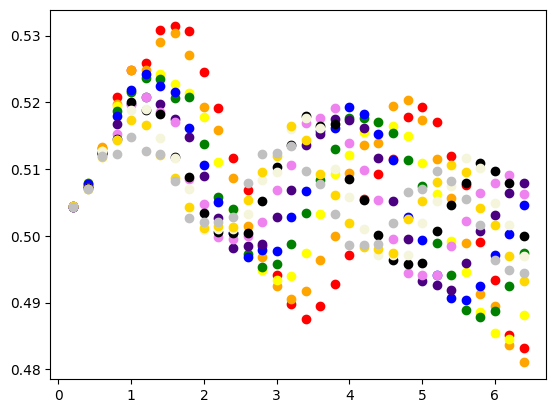

In [45]:
plt.scatter(np.linspace(0.2, 6.4, 32), thing1, color='red')
plt.scatter(np.linspace(0.2, 6.4, 32), points10, color='orange')
plt.scatter(np.linspace(0.2, 6.4, 32), points11, color='yellow')
plt.scatter(np.linspace(0.2, 6.4, 32), points12, color='green')
plt.scatter(np.linspace(0.2, 6.4, 32), points13, color='blue')
plt.scatter(np.linspace(0.2, 6.4, 32), points14, color='indigo')
plt.scatter(np.linspace(0.2, 6.4, 32), points15, color='violet')
plt.scatter(np.linspace(0.2, 6.4, 32), points16, color='black')
plt.scatter(np.linspace(0.2, 6.4, 32), points17, color='beige')
plt.scatter(np.linspace(0.2, 6.4, 32), points18, color='gold')
plt.scatter(np.linspace(0.2, 6.4, 32), points19, color='silver')
plt.show()

In [7]:
thing1

array([0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333])

In [9]:
points18

array([0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333, 0.50491333, 0.50491333, 0.50491333,
       0.50491333, 0.50491333])

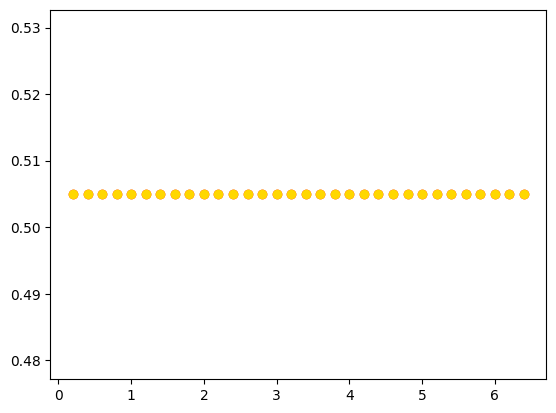

In [10]:
plt.scatter(np.linspace(0.2, 6.4, 32), thing1, color='red')
# plt.scatter(np.linspace(0.2, 6.4, 32), points10, color='orange')
# plt.scatter(np.linspace(0.2, 6.4, 32), points11, color='yellow')
# plt.scatter(np.linspace(0.2, 6.4, 32), points12, color='green')
# plt.scatter(np.linspace(0.2, 6.4, 32), points13, color='blue')
# plt.scatter(np.linspace(0.2, 6.4, 32), points14, color='indigo')
# plt.scatter(np.linspace(0.2, 6.4, 32), points15, color='violet')
# plt.scatter(np.linspace(0.2, 6.4, 32), points16, color='black')
# plt.scatter(np.linspace(0.2, 6.4, 32), points17, color='beige')
plt.scatter(np.linspace(0.2, 6.4, 32), points18, color='gold')
# plt.scatter(np.linspace(0.2, 6.4, 32), points19, color='silver')
plt.show()

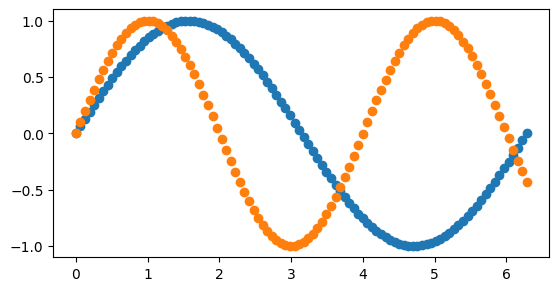

In [181]:
fig, ax = plt.subplots()

plt.scatter(np.linspace(0, 2*np.pi, 100), [np.sin(i) for i in np.linspace(0, 2*np.pi, 100)])
plt.scatter(np.linspace(0, 2*np.pi, 100), [np.sin(np.pi*i/2) for i in np.linspace(0, 2*np.pi, 100)])

ratio = 1/2
x_left, x_right = ax.get_xlim()
y_low, y_high = ax.get_ylim()
ax.set_aspect(abs((x_right-x_left)/(y_low-y_high))*ratio)


In [82]:
def fit_func_alt(x, A, B, C, D, E, F, G, H, I):
    return A+(B*x)+(C*(x**2))+(D*(x**3)) + (E+(F*x)+(G*(x**2))+(H*(x**3)))*np.sin(I*x)

In [152]:
def exp_fit_func(x, A, B, C, D, E):
    return A*np.exp(-B*x) * np.cos(C*x) + D + E*x

In [153]:
ans_9, _ = curve_fit(exp_fit_func, np.linspace(0.2, 6.4, 32), thing1)

In [ ]:
ans_18, _ = curve_fit(exp_fit_func, np.linspace(0.2, 6.4, 32), points18)#, p0=[ 0.48895098,  0.01047784, -0.00174909,  0.04318711, -0.02975097,
        # 0.00446448,  1.45416532])

In [154]:
ans_9

array([-0.01702091, -0.00704371,  1.87221653,  0.5209363 , -0.00412387])

In [159]:
ans_18

array([-7.60703206e-03, -9.36051585e-05, -2.89487122e+00,  5.11279977e-01,
       -1.54868474e-03])

In [162]:
-1.54868474e-03 / -0.00412387

0.37554160048692126

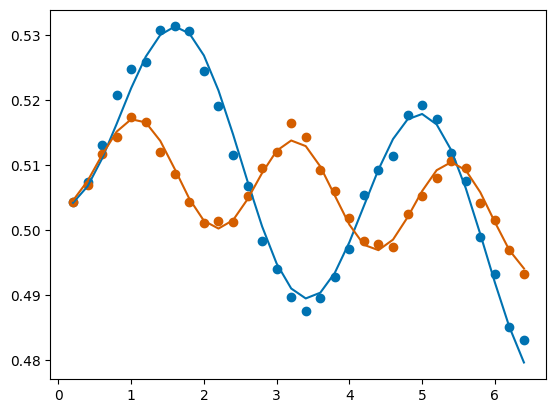

In [175]:
plt.scatter(np.linspace(0.2, 6.4, 32), thing1, color=(0, 114/256, 178/256))
plt.plot(np.linspace(0.2, 6.4, 32), [exp_fit_func(i, *ans_9) for i in np.linspace(0.2, 6.4, 32)], color=(0, 114/256, 178/256))
plt.scatter(np.linspace(0.2, 6.4, 32), points18, color=(213/256, 94/256, 0))
plt.plot(np.linspace(0.2, 6.4, 32), [exp_fit_func(i, *ans_18) for i in np.linspace(0.2, 6.4, 32)], color=(213/256, 94/256, 0))

In [161]:
1.83751421e+00/1.29449456e+00

1.4194839181093197

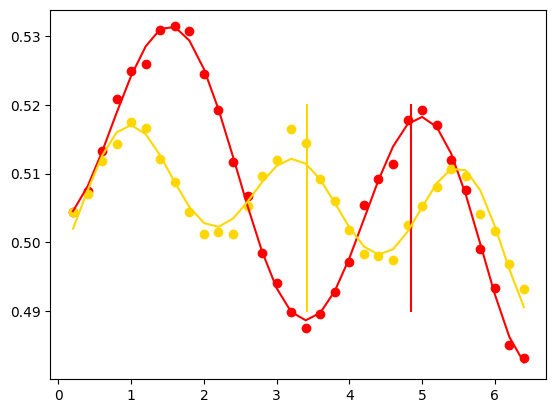

In [124]:
ans_9 = [ 5.03099931e-01,  3.89940932e-03, -1.84110944e-04, -2.27081740e-03,
        2.52743422e-02, -4.91412030e-03,  1.29449456e+00]
ans_18 = [ 4.97497697e-01,  5.87929882e-03, -8.24478763e-05, -1.33824182e-04,
        6.28433018e-03,  1.65783595e-02, -9.57670250e-03,  1.09979136e-03,
        1.83751421e+00]

plt.scatter(np.linspace(0.2, 6.4, 32), thing1, color='red')
plt.plot(np.linspace(0.2, 6.4, 32), [fit_func(i, *ans_9) for i in np.linspace(0.2, 6.4, 32)], color='red')
plt.plot([4.853774980081481]*2, [0.49, 0.52], color='red')
plt.scatter(np.linspace(0.2, 6.4, 32), points18, color='gold')
plt.plot(np.linspace(0.2, 6.4, 32), [fit_func_alt(i, *ans_18) for i in np.linspace(0.2, 6.4, 32)], color='gold')
plt.plot([3.4193941320212082]*2, [0.49, 0.52], color='gold')
plt.show()

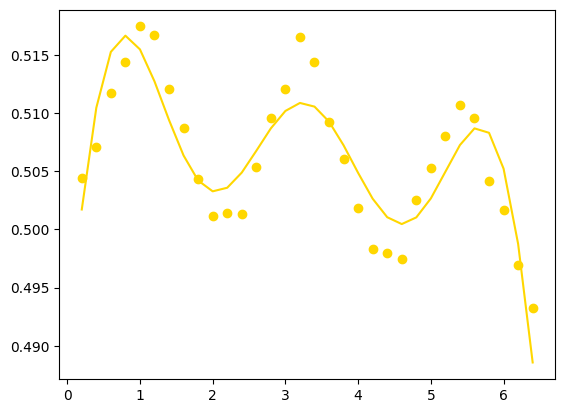

In [73]:
plt.scatter(np.linspace(0.2, 6.4, 32), points18, color='gold')
plt.plot(np.linspace(0.2, 6.4, 32), [fit_func(i,  0.48895073,  0.0104782 , -0.00174917,  0.04318717, -0.02975106,
        0.00446452,  1.45416045) for i in np.linspace(0.2, 6.4, 32)], color='gold')
plt.show()